---
# Commande pour le rendu : quarto render main.ipynb --execute
# Instructions pour quarto
title: "Traitement des données DVF Île-de-France"
format:
  html:
    code-fold: true
    embed-resources: true
---

# Introduction

- **Contexte :** nous exploitons les données des **Demandes de Valeurs Foncières (DVF)** pour analyser les prix des logements (appartements et maisons) en Île-de-France. Ces données fournissent des informations issues des actes notariés et des données cadastrales : valeur du bien, date de mutation, type de bien, surface, localisation, etc.
- **Objectif :** obtenir des **prix immobiliers précis au mètre carré**, par adresse et type de bien, afin de faciliter l’analyse du marché immobilier et son lien éventuel avec l’offre de transport.
- **Données :** nous utilisons les fichiers DVF couvrant les **cinq dernières années**. Ils sont disponibles en **format texte standardisé**, et la documentation complète est consultable [ici](https://www.data.gouv.fr/datasets/demandes-de-valeurs-foncieres).
    - Nettoyage des colonnes essentielles (code département, code postal, adresse)
    - Filtrage pour les départements d’Île-de-France
    - Reconstruction des adresses
    - Agrégation des transactions par adresse et date pour gérer les lots multiples
    - Calcul du **prix au mètre carré**
    - Filtrage des valeurs extrêmes pour éliminer les anomalies
    - Géolocalisation des logements via l’API Base Adresse Nationale (BAN)

# Chargement des données

Nous récupérons les transaction de l'année 2024 à partir de *data.gouv*.

In [1]:
import os
if os.getcwd().endswith("notebooks"):
    os.chdir('..')

import pandas as pd
import numpy as np
import requests

from script.download_data import get_valeur_fonciere_path

file_names = get_valeur_fonciere_path()

with open(file_names, "r", encoding="utf-8") as f:
    lignes = [f.readline().strip() for _ in range(10)]

df = pd.read_csv(file_names, sep="|", low_memory=False)

colonnes_utiles = [
    "Date mutation", 
    "Nature mutation", 
    "Valeur fonciere", 
    "No voie", 
    "Voie",
    "Type de voie",
    "Code voie",
    "Code postal", 
    "Commune",
    "B/T/Q",
    "Code commune",
    "Code departement",
    "Type local", 
    "Code type local",
    "Surface reelle bati", 
    "Nombre pieces principales", 
    "Surface terrain", 
    "1er lot",
    "2eme lot",
    "3eme lot",
    "4eme lot",
    "5eme lot"
]

df_filtre = df[colonnes_utiles]

df_filtre.head(5)

print("Le nombre de lignes dans le DataFrame est :", len(df_filtre))


Téléchargement depuis https://www.data.gouv.fr/api/1/datasets/r/af812b0e-a898-4226-8cc8-5a570b257326
Extraction des ZIP
Extraction terminée
Le nombre de lignes dans le DataFrame est : 3489149


# Traitement 

## Filtrage pour les départements d’Île-de-France

Les données DVF sont nationale et nous souhaitons concentrer nos analyse sur l'Île de France. Nous filtrons les département après avoir vérifié l'absence de valeurs manquantes dans la colonne du dataset et nettoyé celle-ci. 

In [2]:
# Nettoyage de la colonne Code departement
df_filtre.loc[:, "Code departement"] = df_filtre["Code departement"].astype(str).str.strip()

# Filtrage des communes en Ile-de-France
codes_idf = ["75", "77", "78", "91", "92", "93", "94", "95"]
idf = df_filtre[df_filtre["Code departement"].isin(codes_idf)].copy()

print("Le nombre de lignes Ile de France dans le DataFrame est :", len(idf))

Le nombre de lignes Ile de France dans le DataFrame est : 417261


## Reconstruction des adresses 

Nous reconstruson l'adresse des logement à partir des information mis à notre disposition : Numéro de voie, voie et type de voie

In [3]:
#| warning: false
# Assurer que idf est une copie indépendante
idf = idf.copy()

# Convertir en string avant nettoyage
idf.loc[:, "Code postal"] = idf["Code postal"].astype("string").str.replace(".0", "", regex=False).str.strip()
idf.loc[:, "No voie"] = idf["No voie"].astype("string").str.replace(".0", "", regex=False).str.strip()

# Colonnes texte
idf.loc[:, "Type de voie"] = idf["Type de voie"].fillna("").astype(str).str.strip()
idf.loc[:, "Voie"] = idf["Voie"].fillna("").astype(str).str.strip()

# Colonnes vides
idf.loc[:, "x"] = pd.NA
idf.loc[:, "y"] = pd.NA

# Créer une colonne adresse propre
idf.loc[:, "adresse"] = (
    idf["No voie"] + " " +
    idf["Type de voie"] + " " +
    idf["Voie"]
).str.replace(" +", " ", regex=True).str.strip()


/tmp/ipykernel_3955/3269145529.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '<StringArray>
['77350', '77350', '77350', '77390', '77390', '77350', '77000', '77000',
 '77000', '77000',
 ...
 '75015', '75011', '75011', '75011', '75013', '75007', '75006', '75006',
 '75015', '75011']
Length: 417261, dtype: string' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  idf.loc[:, "Code postal"] = idf["Code postal"].astype("string").str.replace(".0", "", regex=False).str.strip()
/tmp/ipykernel_3955/3269145529.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '<StringArray>
['9002',  '177',  '177',  '193',  '193', '9002',   '45',   '45',   '45',
   '45',
 ...
   '59',   '88',   '88',   '88',   '50',  '176',    '7',    '7',  '100',
   '45']
Length: 417261, dtype: string' has dtype incompatible with float64, ple

## Agrégation des transactions par adresse et date pour gérer les lots multiples

Certaines transactions immobilières dans les fichiers DVF concernent plusieurs lots (par exemple, un immeuble vendu en plusieurs parties ou un bien cadastral divisé).  
Si chaque lot était conservé séparément, cela entraînerait un **double comptage** des biens et biaiserait les calculs de surface totale, de nombre de pièces et du prix au mètre carré.  

Pour corriger cela, nous effectuons une **agrégation par adresse et date de mutation**.  
Chaque groupe de lignes correspondant à une même adresse et à la même date est considéré comme une **transaction unique**.  

Lors de cette agrégation :  
- La **valeur foncière** est soit conservée telle quelle si identique pour tous les lots, soit sommée pour refléter l’ensemble des lots.  
- Le **code postal** et la **commune** sont pris à partir de la première valeur du groupe, car elles sont identiques pour tous les lots.  
- La **surface réelle bâtie**, la **surface du terrain** et le **nombre de pièces principales** sont **sommées** pour obtenir les totaux correspondant à l’ensemble des lots.  
- Le **code commune** et le **type de local** sont pris à partir de la première valeur non manquante, afin de préserver l’information principale du bien.  

Cette opération garantit que chaque transaction est comptabilisée **une seule fois**, et que les mesures de surface et de composition du bien sont exactes.  
C’est une étape essentielle pour calculer un **prix au mètre carré fiable** et pour réaliser des analyses statistiques précises.

In [4]:
def valeur_fonciere_agg(x):
    if len(x.unique()) == 1:
        return x.iloc[0]
    else:
        return pd.to_numeric(x, errors='coerce').sum()

def sum_numeric(x):
    return pd.to_numeric(x, errors='coerce').sum()

idf = (
    idf
    .groupby(["adresse", "Date mutation"], as_index=False)
    .agg({
        "Valeur fonciere": valeur_fonciere_agg,
        "Code postal": "first",
        "Commune": "first",
        "Surface reelle bati": sum_numeric,
        "Surface terrain": sum_numeric,
        "Nombre pieces principales": sum_numeric,
        "Code commune": lambda x: x.dropna().iloc[0] if len(x.dropna()) > 0 else pd.NA,
        "Type local": lambda x: x.dropna().iloc[0] if len(x.dropna()) > 0 else pd.NA
    })
)

print("Le nombre de transaction en Ile de France dans le DataFrame est :", len(idf))

Le nombre de transaction en Ile de France dans le DataFrame est : 160194


## Nettoyage des données et traitement des valeurs aberrantes

Cette étape vise à nettoyer les données DVF et à éliminer les **valeurs aberrantes** afin d’obtenir un indicateur de **valeur foncière au mètre carré** fiable et exploitable pour l’analyse.

## Étapes principales
1. **Filtrage des biens et des surfaces**  
   - Suppression des observations dont la **surface réelle bâtie** est manquante.  
   - Conversion de la surface réelle bâtie en format numérique.  
   - Conservation uniquement des biens dont la surface est comprise entre **9 m² et 300 m²**, afin d’exclure les valeurs irréalistes.  
   - Sélection des **maisons et appartements** uniquement, pour se concentrer sur le résidentiel.  
   - Suppression des lignes avec une **valeur foncière manquante**.

2. **Nettoyage de la valeur foncière**  
   - La variable **valeur foncière** est nettoyée pour garantir un format numérique homogène.

3. **Calcul de la valeur foncière au mètre carré**  
   - La **valeur foncière au mètre carré** est calculée comme le rapport entre la valeur foncière et la surface réelle bâtie.

4. **Analyse des distributions avant filtrage**  
   - Calcul des **déciles** de la valeur foncière au mètre carré afin d’observer la distribution.  
   - Identification des valeurs minimale et maximale.  
   - Comptage du nombre d’observations avant filtrage.

5. **Traitement des valeurs aberrantes**  
   - Conservation uniquement des biens dont la **valeur foncière au mètre carré** est comprise entre **1 000 € et 20 000 €**.  
   - Suppression des observations situées en dehors de cet intervalle.
   - Pour le nombre de **pièces principales**, si la **surface moyenne par pièce d’un appartement est inférieure à 5 m²**, la valeur est considérée comme incohérente et remplacée par NA.
   - Pour la **surface du terrain**, les biens dont la taille dépasse **10 000 m²** sont considérés comme aberrants et remplacés par NA.

6. **Analyse après filtrage**  
   - Recalcul des **déciles** après suppression des valeurs aberrantes.  
   - Comparaison du nombre d’observations avant et après filtrage.  
   - Vérification des nouvelles valeurs minimale et maximale.

Cette démarche permet de réduire l’influence des valeurs extrêmes, d’améliorer la robustesse des statistiques descriptives et d’assurer la fiabilité des analyses de prix immobiliers.


In [5]:
idf = idf[idf["Surface reelle bati"].notna()]
idf["Surface reelle bati"] = pd.to_numeric(idf["Surface reelle bati"])
idf = idf[(idf["Surface reelle bati"] >= 9) & (idf["Surface reelle bati"] <= 300)]
idf = idf[idf["Type local"].isin(["Maison", "Appartement"])]

print("Le nombre de transaction immobilière (Appartement et Maison) avec une surface cohérente en Ile de France dans le DataFrame est :", len(idf))

idf = idf.dropna(subset=["Valeur fonciere"])

idf["Valeur fonciere"] = (
    idf["Valeur fonciere"]
        .astype(str)
        .str.replace(" ", "", regex=False)
        .str.replace(",", ".", regex=False)
        .str.replace("\xa0", "", regex=False)
        .str.extract(r'(\d+\.?\d*)')[0]
        .astype(float)
)

idf["Valeur foncière au mètre carré"] = (
    idf["Valeur fonciere"] / idf["Surface reelle bati"]
)

n_superieur_100000 = (idf["Valeur foncière au mètre carré"] > 100000).sum()
print(f"Nombre de transactions > 100 000 €/m² : {n_superieur_100000}")

idf = idf.loc[
    (idf["Valeur foncière au mètre carré"] <= 100000)
]


Le nombre de transaction immobilière (Appartement et Maison) avec une surface cohérente en Ile de France dans le DataFrame est : 75627
Nombre de transactions > 100 000 €/m² : 46


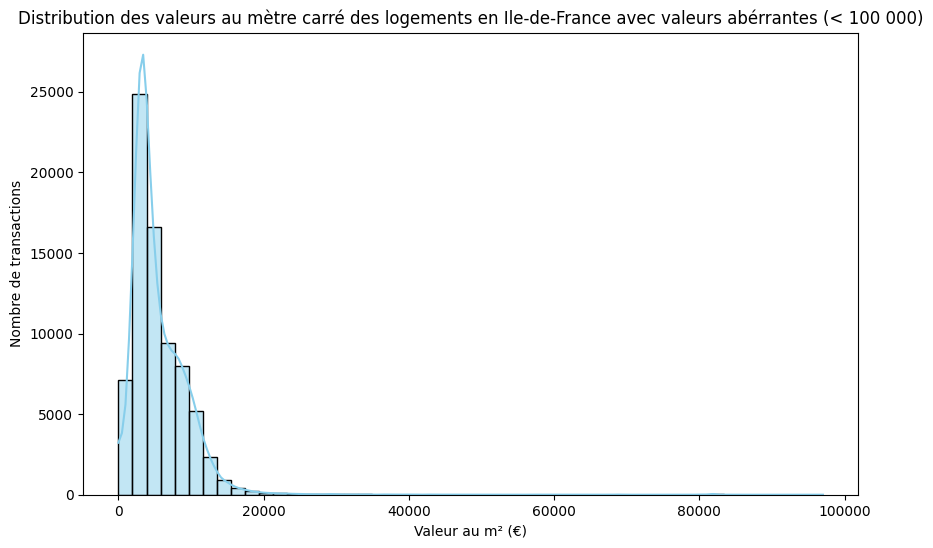

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(idf["Valeur foncière au mètre carré"], bins=50, kde=True, color="skyblue")
plt.title("Distribution des valeurs au mètre carré des logements en Ile-de-France avec valeurs abérrantes (< 100 000)")
plt.xlabel("Valeur au m² (€)")
plt.ylabel("Nombre de transactions")
plt.show()


In [7]:
n_inferieur_1000 = (idf["Valeur foncière au mètre carré"] < 1000).sum()
n_superieur_20000 = (idf["Valeur foncière au mètre carré"] > 20000).sum()

print(f"Nombre de transactions < 1 000 €/m² : {n_inferieur_1000}")
print(f"Nombre de transactions > 20 000 €/m² : {n_superieur_20000}")

idf = idf.loc[
    (idf["Valeur foncière au mètre carré"] >= 1000) &
    (idf["Valeur foncière au mètre carré"] <= 20000)
]

print("Le nombre de transaction immobilière (Appartement et Maison) avec une surface et un prix au mêtre carré cohérents en Ile de France dans le DataFrame est :", len(idf))

Nombre de transactions < 1 000 €/m² : 2474
Nombre de transactions > 20 000 €/m² : 444
Le nombre de transaction immobilière (Appartement et Maison) avec une surface et un prix au mêtre carré cohérents en Ile de France dans le DataFrame est : 72618


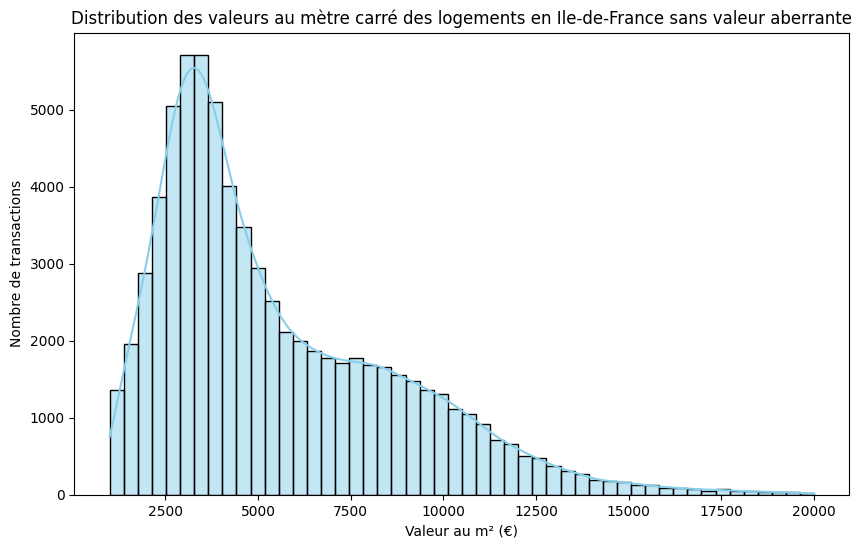

In [8]:
plt.figure(figsize=(10,6))
sns.histplot(idf["Valeur foncière au mètre carré"], bins=50, kde=True, color="skyblue")
plt.title("Distribution des valeurs au mètre carré des logements en Ile-de-France sans valeur aberrante")
plt.xlabel("Valeur au m² (€)")
plt.ylabel("Nombre de transactions")
plt.show()

In [9]:
idf["Nombre pieces principales"] = pd.to_numeric(idf["Nombre pieces principales"], errors="coerce")
idf["surface_par_piece"] = idf["Surface reelle bati"] / idf["Nombre pieces principales"]
seuil_min_surface_par_piece = 9
mask_aberrant = (
    (idf["Nombre pieces principales"].isna()) |
    (idf["Nombre pieces principales"] <= 0) |
    (idf["surface_par_piece"] < seuil_min_surface_par_piece)
)
idf_aberrantes = idf.loc[mask_aberrant].copy()
print(f"Nombre de lignes avec nombre de pièces aberrant : {mask_aberrant.sum()}")

idf.loc[mask_aberrant, ["Surface reelle bati", "Nombre pieces principales"]] = np.nan
idf.drop(columns="surface_par_piece", inplace=True)
idf_aberrantes.head(5)

Nombre de lignes avec nombre de pièces aberrant : 190


,adresse,Date mutation,Valeur fonciere,Code postal,Commune,Surface reelle bati,Surface terrain,Nombre pieces principales,Code commune,Type local,Valeur foncière au mètre carré,surface_par_piece
900,1 AV DE L'EUROPE,26/09/2024,94600.0,91560,CROSNE,16.0,0.0,2.0,191,Appartement,5912.500000,8.000000
5148,1 RUE FERNAND PELLOUTIER,26/06/2024,147000.0,92100,BOULOGNE-BILLANCOURT,17.0,0.0,2.0,12,Appartement,8647.058824,8.500000
5984,1 RUE MILLION,19/07/2024,95640.0,78350,JOUY EN JOSAS,16.0,0.0,0.0,322,Appartement,5977.500000,inf
7131,10 ALL DU QUERCY,15/01/2024,500000.0,78570,ANDRESY,112.0,571.0,15.0,15,Maison,4464.285714,7.466667
7327,10 AV DE PARIS,11/04/2024,235000.0,94300,VINCENNES,28.0,0.0,0.0,80,Appartement,8392.857143,inf


In [10]:
print("Distribution des surfaces de terrain :")
print(idf["Surface terrain"].describe().to_string())
na_avant = idf["Surface terrain"].isna().sum()
idf["Surface terrain"] = pd.to_numeric(idf["Surface terrain"], errors="coerce")
limite_max_terrain = 10000  # tu peux ajuster selon le contexte
idf.loc[idf["Surface terrain"] > limite_max_terrain, "Surface terrain"] = np.nan
na_apres = idf["Surface terrain"].isna().sum()

nb_na_crees = na_apres - na_avant
print(f"Nombre de valeurs aberrante retirées pour la surface du terrain : {nb_na_crees}")

Distribution des surfaces de terrain :
count     72618.000000
mean        210.014074
std         786.629170
min           0.000000
25%           0.000000
50%           0.000000
75%         263.000000
max      116408.000000
Nombre de valeurs aberrante retirées pour la surface du terrain : 38


# Géocodage des adresses avec l'API Adresse de data.gouv.fr

Cette étape permet de **transformer les adresses textuelles en coordonnées géographiques** (latitude et longitude) via l’API officielle `https://api-adresse.data.gouv.fr`.

Les étapes effecutées sont les suivantes : 

1. **Nettoyage et uniformisation des adresses**  
   - Suppression des arrondissements de Paris (`PARIS 1`, `PARIS 2`, … → `PARIS`).  
   - Renommage et vérification des colonnes : `Code postal`, `adresse`, `Commune`.

2. **Création d’une colonne "search"**  
   - Combinaison de l’adresse, du code postal et de la commune pour former une chaîne unique.  
   - Cette colonne servira de référence pour le géocodage.

3. **Exportation vers CSV**  
   - Les adresses préparées sont sauvegardées dans un fichier `idfs.csv`.  
   - Le CSV sera envoyé à l’API pour traitement en lot.

4. **Envoi du fichier à l’API**  
   - Une requête POST transmet le CSV à l’API `https://api-adresse.data.gouv.fr/search/csv/`.  
   - L’API retourne un CSV géocodé avec les coordonnées et les informations normalisées.

5. **Gestion de la réponse**  
   - Si la requête réussit (`status_code == 200`), le CSV géocodé est sauvegardé localement (`idfs_geocoded.csv`).  
   - Sinon, le script affiche un message d’erreur.

6. **Lecture du CSV géocodé**  
   - Le fichier retourné est lu dans un DataFrame `idfs_geocoded` pour les analyses spatiales ou cartographiques.




In [11]:
# preparation du dossier de cache
from pathlib import Path
cache_path = Path("cache/geocoding")
cache_path.mkdir(parents=True, exist_ok=True)

FILE_IDFS = cache_path / "idfs.csv"
FILE_IDFS_GEOCODED = cache_path / "idfs_geocoded.csv"

idf["Commune"] = idf["Commune"].str.replace(r"PARIS \d{1,2}", "PARIS", regex=True)

idf = idf.rename(columns={
    "Code postal": "Code_postal",
    "adresse": "adresse",   # juste pour s'assurer que c'est correct
    "Commune": "Commune"
})

idf["search"] = idf["adresse"].astype(str) + " " + idf["Code_postal"].astype(str) + " " + idf["Commune"]

if not os.path.exists(FILE_IDFS_GEOCODED): # ne pas refaire la requete si déjà en cache
    # Géocodage des adresses en Ile de France

    idf_search = idf["search"]
    idf_search.to_csv(FILE_IDFS, index=False, encoding="utf-8")


    payload = {
        "indexes": ["address"],
    }

    url = "https://api-adresse.data.gouv.fr/search/csv/"
    files = {"data": open(FILE_IDFS, "rb")}
    response = requests.post(url, files=files)

    if response.status_code == 200:
        # Sauvegarde le CSV retourné tel quel
        with open(FILE_IDFS_GEOCODED, "wb") as f:
            f.write(response.content)
        print("CSV géocodé sauvegardé avec succès !")
    else:
        print("Erreur API :", response.text)

idfs_geocoded = pd.read_csv(FILE_IDFS_GEOCODED, low_memory=False)

idf = idf.merge(
    idfs_geocoded,
    on=["search"], 
    how="left"
)

# Retirer les lignes avec NaN dans latitude ou longitude
idf = idf.dropna(subset=["latitude", "longitude"])

print(len(idf), "transactions cohérentes ont été géolocalisées en Ile de France")

CSV géocodé sauvegardé avec succès !
116157 transactions cohérentes ont été géolocalisées en Ile de France


# Export des données nettoyées

- Suppression des doublons créés à l'étape de géolocalisation 
- Conservation uniquement des colonnes utiles pour l'analyse et la valorisation.  
- Export du DataFrame nettoyé dans `script/prix_logements.csv` pour usage ultérieur.


In [12]:
idf = idf.drop_duplicates(subset=["search", "Date mutation"], keep="first")

print("Nombre de transactions après suppression des doublons :", len(idf))

import geopandas as gpd
from pathlib import Path

CRS_GTFS = "EPSG:4326" # TODO vérifier si c'est le bon CRS

# creation du dossier de sauvegarde s'il n'existe pas
dir_path = Path("cache/results")
dir_path.mkdir(parents=True, exist_ok=True)

colonnes_utiles = ['adresse', 'Date mutation', 'Valeur fonciere', 'Code_postal', 'Code commune',
       'Surface reelle bati', 'Surface terrain', 'Nombre pieces principales',
       'Type local', 'Valeur foncière au mètre carré', 'longitude', 'latitude', 'result_score']

idf_gdf = gpd.GeoDataFrame(
    idf,
    geometry=gpd.points_from_xy(idf.longitude, idf.latitude),
    crs="EPSG:4326"
)

idf_gdf = idf_gdf.drop(["longitude", "latitude"], axis=1)

idf_gdf.to_file("cache/results/prix_logements.geojson", driver="GeoJSON", encoding="utf-8")

Nombre de transactions après suppression des doublons : 72613


# Visualisations

## Affichage d'un échantillon de transactions

Une première visualisation nous permet de vérifier la distribution et la cohérence de nos données.

On utilise `folium` pour afficher un échantillon des transactions dont nous disposons. Les points sont colorés en fonction de leur valeur foncière par metres carrés.

:::{.callout-note}
Cliquer sur les cartes pour accéder à la version interactive
::: 

In [17]:
import geopandas as gpd

import folium
import branca.colormap as cm
from numpy import log

import os
if os.getcwd().endswith("notebooks"):
    os.chdir('..')
    
from script.leaflet_tools import FondCarteLeaflet

m = FondCarteLeaflet(afficher_grande_couronne=True).get_map()
idf = gpd.read_file("cache/results/prix_logements.geojson")


idf_sample = idf.sample(frac = 0.03, random_state= 42)

print(f"Visualisation de {len(idf_sample)} points sur {len(idf)}.")

cmap = cm.LinearColormap(
    colors=['#d9d9d9', 'red'],
    vmin=idf_sample['Valeur foncière au mètre carré'].min(),
    vmax=idf_sample['Valeur foncière au mètre carré'].max(),
    caption='Valeur foncière au m² (€)'
)

for _, row in idf_sample.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x], 
        radius=0.5,
        tooltip=f"{row['adresse']} : {row['Valeur foncière au mètre carré']:.0f} €/m²",
        color=cmap(row['Valeur foncière au mètre carré']),
        fill=True,
        fill_color=cmap(row['Valeur foncière au mètre carré']),
        fill_opacity=0.7
    ).add_to(m)

# Ajouter la légende
cmap.add_to(m)

# Sauvegarde de la carte dans assets/maps/dvf1.html
import folium
from pathlib import Path

assets = Path("assets/maps")
assets.mkdir(parents=True, exist_ok=True)

m.save(assets / "dvf1.html")


Téléchargement des bordures de communes / départements
Téléchargement : borders=DEPARTEMENT, filter_by=REGION, values=['11'] ...
Départements récupérés : 8 entités, sauvegardé dans : cache/cartiflette/departements_idf.geojson
Téléchargement : borders=COMMUNE_ARRONDISSEMENT, filter_by=REGION, values=['11'] ...
Communes récupérées : 1287 entités sauvegardé dans : cache/cartiflette/communes_idf.geojson
Visualisation de 2178 points sur 72613.


[![Interactive map](/assets/maps/dvf1.png)](/assets/maps/dvf1.html)

Plus on s'approche du centre de paris plus les ventes sont nombreuses et plus les logements sont chers. Cela est cohérent.


## Carte des prix au m²

### Création de la carte

Pour obtenir une **vision fine du prix au mètre carré**, nous découpons la région en une grille de taille variable

La taille des mailles est de 500m x 500m dans la petite couronne et de 2000m x 2000m dans la grande couronne. Ce choix constitue un compromis entre **précision spatiale** et **nombre de transactions par cellule** (car la densité de logement étant plus faible dans la grande couronne).

Dans chaque cellule, nous calculons le **prix moyen au m²** à condition d’avoir au moins 5 transactions (afin d'éviter une grande variabilitée due aux cellules contenant peu de ventes).  

In [18]:
from script.leaflet_tools import creation_heatmap, display_heatmap

# dans la petite couronne carrés de 500m x 500m
codes_petite_couronne = ["75", "92", "93", "94"]
idf = idf.copy()
idf["code_dep"] = idf["Code_postal"].astype(str).str[:2]

df_pc = idf[idf["code_dep"].isin(codes_petite_couronne)].copy()

df500 = creation_heatmap(
    df_pc,
    cell_size=500,
    target_value_col="Valeur foncière au mètre carré",
    min_points_per_cell=5
)

# dans la grande couronne carrés de 2000m x 2000m
df_gc = idf[~idf["code_dep"].isin(codes_petite_couronne)].copy()

df2K = creation_heatmap(
    df_gc,
    cell_size=2000,
    target_value_col="Valeur foncière au mètre carré",
    min_points_per_cell=5
)

# fusion des deux heatmaps
grille_complete = pd.concat([df500, df2K], ignore_index=True)
grille_complete = grille_complete[grille_complete["nb_points"] >= 5]

m = display_heatmap(
    grille_complete,
    target_value_col="moyenne",
    cmap="default", # choix de la colormap par défaut
    default_cmap_caption="Prix moyen au m² (€)",
    legend=["Prix moyen €/m² :", "Nb transactions :"]
)

m.save(assets / "dvf2.html")

[![Interactive map](/assets/maps/dvf2.png)](/assets/maps/dvf2.html)


On retrouve les prix au m² connus en Île-de-France. On peut voir que les prix moyens diminuent rapidement lorsqu'on séloigne du centre de Paris.

### Vérification de la variabilité

On peut se demander si les prix des logements sont homogènes dans les cellules que nous avons créé.

Pour cela nous calculons également :  
- le **coefficient de variation intra-carré**, qui mesure la dispersion des prix à l’intérieur de chaque cellule. 
- la **coefficient de variation inter-carré**, qui mesure la dispersion des moyennes entre les cellules.

Ces mesures sont importantes car elles permettent de vérifier **l’homogénéité interne des cellules** et **la pertinence des comparaisons entre cellules**, ce qui garantit que la carte reflète fidèlement les variations spatiales des prix.  

In [26]:
grille_complete["coeff_variation"] = (
    (np.sqrt((grille_complete["variance"])) / grille_complete["moyenne"]) * 100
)

m = display_heatmap(
    grille_complete[grille_complete["nb_points"] >= 10], # cellules avec au moins 10 transactions pour plus de fiabilité
    target_value_col="coeff_variation",
    cmap = "no_grey",
    default_cmap_caption="Coefficient de variation du prix moyen (en %)",
    legend=["CV (%):", "Nb transactions :"]
)

print("Coefficient de variation moyen intra-carré :", grille_complete["coeff_variation"].mean(), "%")
print("Coefficient de variation inter-carré :", (grille_complete["moyenne"].std() / grille_complete["moyenne"].mean()) * 100, "%")

m.save(assets / "dvf3.html")

Coefficient de variation moyen intra-carré : 29.242175213559985 %
Coefficient de variation inter-carré : 49.175226773128564 %


[![Interactive map](/assets/maps/dvf3.png)](/assets/maps/dvf3.html)

On peut voir que le le coefficient de variation intra-carré est très faible sur toute la carte (<2%). Ce qui indique que la moyenne par cellule est représentative des transactions locales.  

Le coefficient de variation inter-carré est lui élevée ce qui indique de fortes variations de prix les différents quartier (ce qu'on pouvait déjà voir sur la carte précédente).

Notre cadrillage est donc très adapté pour décrire finemement les variation de prix au m² en Île-de-France

# Analyse descriptive des transactions immobilières en Île-de-France

Cette étape permet de **comprendre la répartition des biens immobiliers** et la variation des prix au m² selon le type de local et la zone géographique.

## Étapes principales

1. **Séparation par type de bien**  
   - Les transactions sont regroupées en **Appartements** et **Maisons**.  
   - Calcul des statistiques descriptives pour chaque type :  
     - Valeur foncière au m² : moyenne, médiane, écart-type, minimum et maximum  
     - Surface réelle bâtie : moyenne, médiane, étendue  
     - Surface terrain : moyenne, médiane, étendue  
     - Nombre de pièces principales : moyenne, médiane, étendue

2. **Visualisation des distributions par type**  
   - Histogrammes avec courbes de densité pour chaque variable.  
   - Permet de visualiser :  
     - La concentration des biens autour de valeurs typiques  
     - Les valeurs extrêmes ou aberrantes normalement déjà traités

3. **Création d’une colonne "zone"**  
   - Classification des transactions selon la localisation :  
     - **Paris** (75)  
     - **Petite couronne** (92, 93, 94)  
     - **Ile-de-France** (autres départements)  
   - Cette colonne permet de comparer les zones et de calculer la part d’appartements dans chaque zone.

4. **Statistiques par zone**  
   - Calcul des mêmes statistiques descriptives que pour les types de biens.  
   - Observation des différences :  
     - Paris : prix au m² élevés, surfaces plus petites  
     - Petite couronne : prix intermédiaires, surfaces légèrement plus grandes  
     - Ile-de-France : prix plus bas, surfaces souvent plus grandes

5. **Visualisation par zone**  
   - Histogrammes et boxplots pour chaque zone afin de comparer la distribution des prix, surfaces et nombre de pièces.  
   - Ces graphiques mettent en évidence la répartition des biens et la dispersion des prix selon la localisation.
 biens autour de valeurs typiques


In [27]:
grouped_type = (
    idf
    .groupby("Type local")[[
        "Valeur foncière au mètre carré",
        "Surface reelle bati",
        "Surface terrain",
        "Nombre pieces principales"
    ]]
    .agg(["mean", "median", "std", "min", "max"])
    .round(2)
)

grouped_type




Valeur foncière au mètre carré                                     \
                                      mean   median      std     min      max   
Type local                                                                      
Appartement                        6420.19  5753.42  3415.46  1000.0  20000.0   
Maison                             3959.06  3460.23  2199.03  1000.0  20000.0   

            Surface reelle bati                           Surface terrain  \
                           mean median    std  min    max            mean   
Type local                                                                  
Appartement               54.31   49.0  31.85  9.0  300.0           17.74   
Maison                   105.91   95.0  47.76  9.0  300.0          525.99   

                                        Nombre pieces principales         \
            median     std  min     max                      mean median   
Type local                                                                 
Appartement    0.0  216.23  0.0  9204.0                      2.55    2.0   
Maison       398.0  604.39  0.0  9940.0                      4.75    4.0   

                              
              std  min   max  
Type local                    
Appartement  1.36  1.0  20.0  
Maison       1.89  1.0  20.0

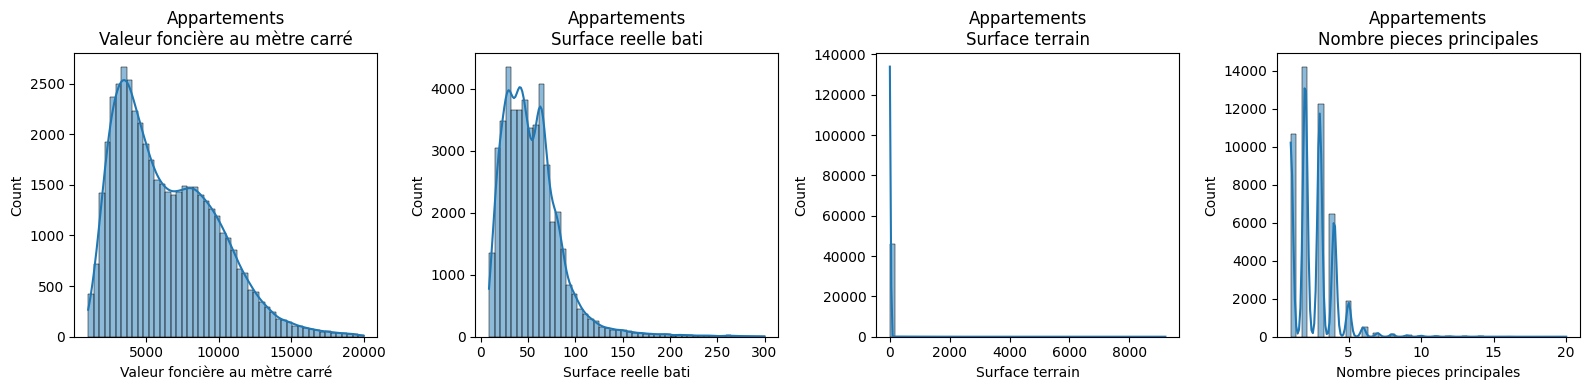

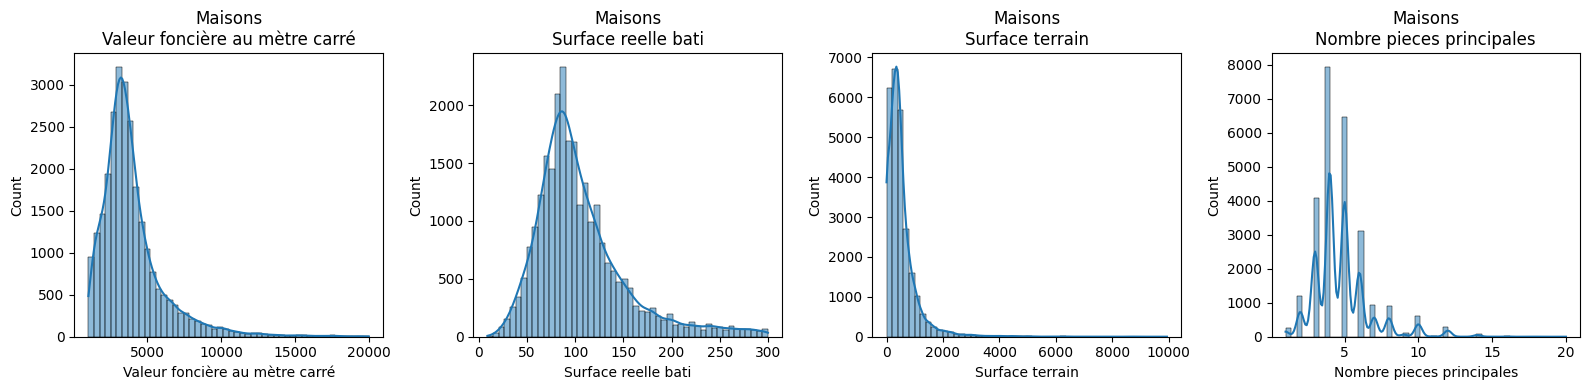

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
appartements = idf[idf['Type local'] == 'Appartement']
maisons = idf[idf['Type local'] == 'Maison']

colonnes = ['Valeur foncière au mètre carré', 'Surface reelle bati', 'Surface terrain', 'Nombre pieces principales']

def plot_distributions(data, title):
    plt.figure(figsize=(16, 4))
    for i, col in enumerate(colonnes):
        plt.subplot(1, 4, i+1)
        sns.histplot(data[col], bins=50, kde=True)
        plt.title(f"{title}\n{col}")
        plt.xlabel(col)
    plt.tight_layout()
    plt.show()

plot_distributions(appartements, "Appartements")
plot_distributions(maisons, "Maisons")

In [29]:

paris = ['75']
petite_couronne = ['92','93','94']

def zone_dep(dep):
    if dep in paris:
        return 'Paris'
    elif dep in petite_couronne:
        return 'Petite couronne'
    else:
        return 'Ile de France'

idf['zone'] = idf['code_dep'].astype(str).apply(zone_dep)
counts = idf.groupby(['zone', 'Type local']).size().unstack(fill_value=0)

counts['part_appartement'] = counts['Appartement'] / counts.sum(axis=1) * 100
counts[['part_appartement']].rename

<bound method DataFrame.rename of Type local       part_appartement
zone                             
Ile de France           40.224850
Paris                   99.501308
Petite couronne         72.796055>

In [30]:
grouped_type = (
    idf
    .groupby('zone')[[
        "Valeur foncière au mètre carré",
        "Surface reelle bati",
        "Surface terrain",
        "Nombre pieces principales"
    ]]
    .agg(["mean", "median", "std", "min", "max"])
    .round(2)
)

grouped_type



Valeur foncière au mètre carré                            \
                                          mean   median      std     min   
zone                                                                       
Ile de France                          3476.03  3265.31  1545.49  1000.0   
Paris                                  9685.98  9502.79  2835.18  1000.0   
Petite couronne                        5503.45  5156.25  2428.35  1000.0   

                         Surface reelle bati                            \
                     max                mean median    std  min    max   
zone                                                                     
Ile de France    17750.0               88.91   80.0  48.21  9.0  300.0   
Paris            20000.0               47.82   38.0  35.17  9.0  298.0   
Petite couronne  20000.0               67.83   62.0  38.88  9.0  300.0   

                Surface terrain                              \
                           mean median     std  min     max   
zone                                                          
Ile de France            357.94  160.5  606.89  0.0  9940.0   
Paris                      1.53    0.0   47.79  0.0  4680.0   
Petite couronne          118.46    0.0  313.08  0.0  8108.0   

                Nombre pieces principales                          
                                     mean median   std  min   max  
zone                                                               
Ile de France                        4.04    4.0  2.03  1.0  20.0  
Paris                                2.23    2.0  1.30  1.0  16.0  
Petite couronne                      3.13    3.0  1.58  1.0  17.0

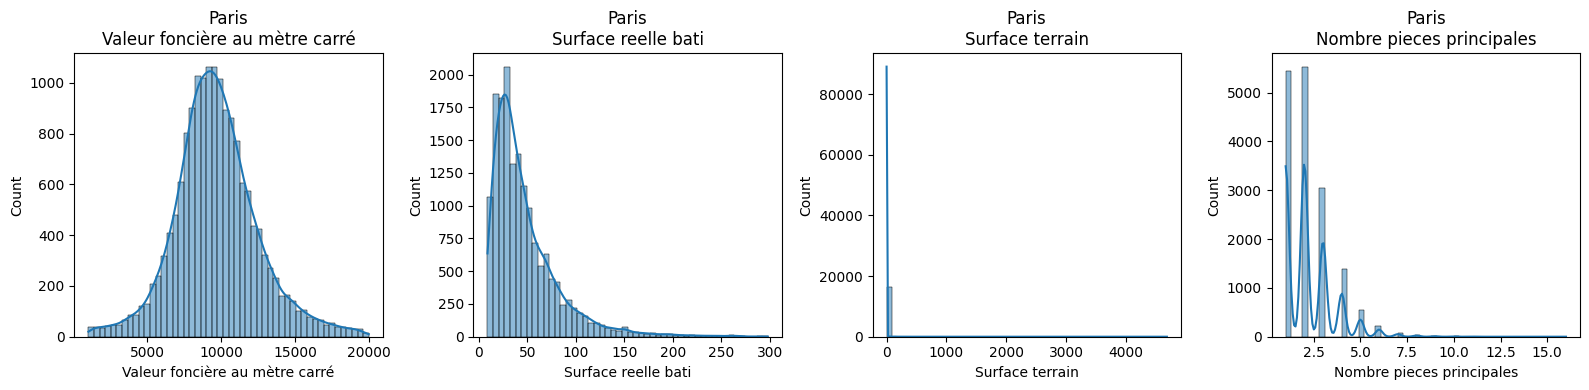

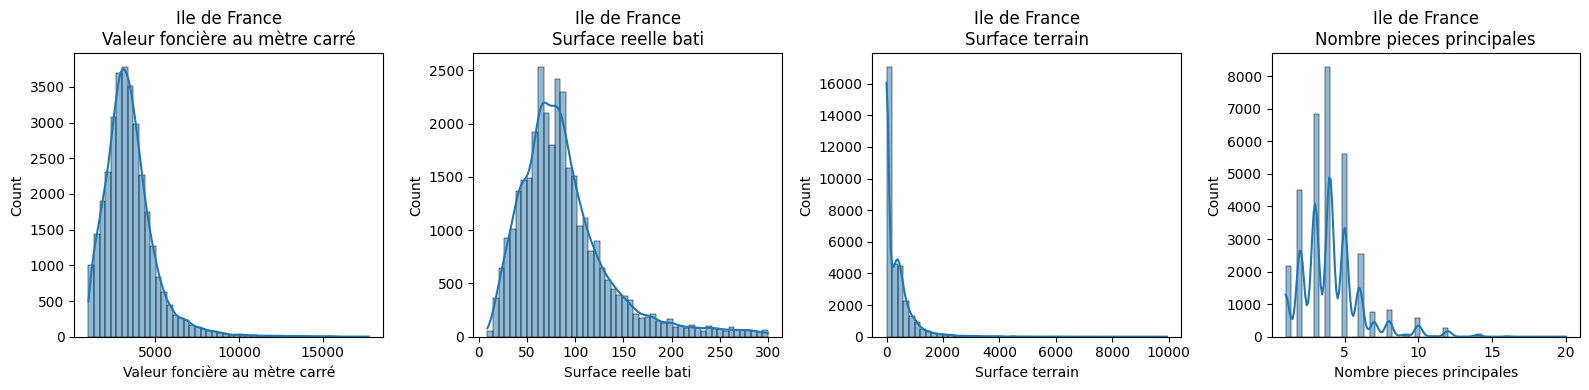

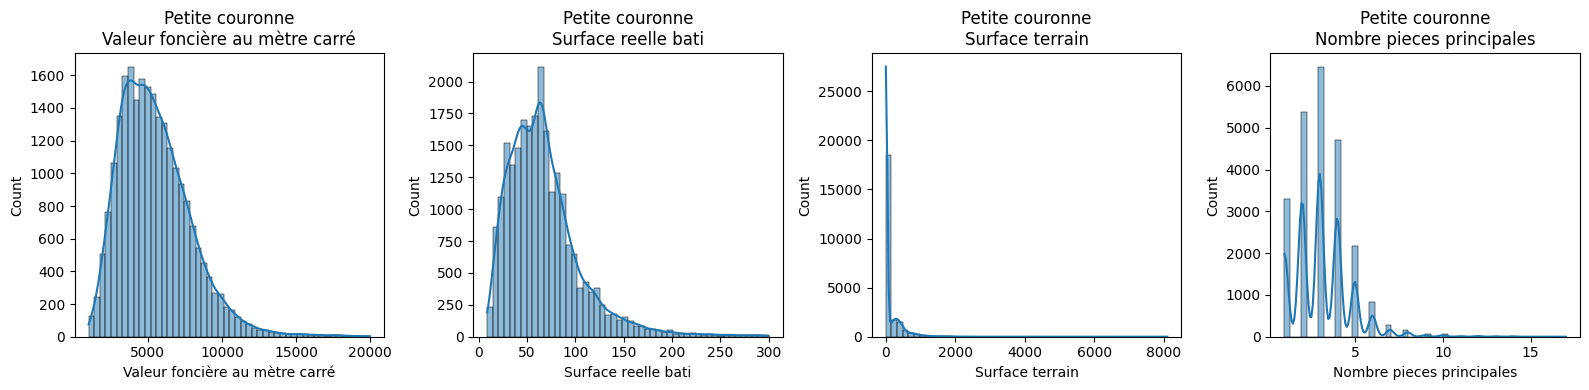

In [31]:


Par = idf[idf['zone'] == 'Paris']
IdF = idf[idf['zone'] == 'Ile de France']
Pc = idf[idf['zone'] == 'Petite couronne']

colonnes = ['Valeur foncière au mètre carré', 'Surface reelle bati', 'Surface terrain', 'Nombre pieces principales']

def plot_distributions(data, title):
    plt.figure(figsize=(16, 4))
    for i, col in enumerate(colonnes):
        plt.subplot(1, 4, i+1)
        sns.histplot(data[col], bins=50, kde=True)
        plt.title(f"{title}\n{col}")
        plt.xlabel(col)
    plt.tight_layout()
    plt.show()


plot_distributions(Par, "Paris") 
plot_distributions(IdF, "Ile de France") 
plot_distributions(Pc, "Petite couronne")